In [1]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import datasets.data_loader as data_loader
from utils import generate_dataset

import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.io import loadmat
import os
import numpy as np
from collections import Counter
import csv

# Load Model
from models.model_components import maskCNNModel, classificationHybridModel, CALoRa, CALoRa_extract
import torch.optim as optim

from collections import defaultdict, Counter
import random
import pandas as pd

torch.cuda.empty_cache()

## `Class Opts` : 예측 파라미터 및 입력 전처리 정리

이 노트북에서는 예측에 필요한 설정값들을 한 곳에서 관리하기 위해 `Opts` 클래스를 정의한다.  
`Opts`는 다음과 같은 정보를 모아두는 역할을 한다.

- **학습 / 예측에 필요한 파라미터**
  - LoRa 관련 파라미터 : 확산 계수(SF, Spreading Factor), 대역폭(BW, Bandwidth), 클래스 수(n_classes), SNR 등
  - 모델 관련 파라미터 : 채널 수, 학습/테스트 비율 등
  - 스펙트로그램 관련 파라미터 : `NFFT` 크기($2^{SF}\times \frac{Fs}{BW}$), `Window 크기` : $2^{SF-1}$, `Overlap 크기` : $2^{SF-2}$, Crop 크기 : 추후 원본 스펙트로그램(OS, OverSampling)에서 주파수 영역을 나누는 크기
  - 배치 크기, 디바이스(`cpu` / `cuda`)와 같은 학습·추론 환경 설정
  - 학습된 모델 가중치 파일 경로, 테스트 데이터 경로 등
  - 정답 스펙트로그램의 SNR 등

- **모델 입력에 사용되는 함수**
  - IQ 시계열 데이터를 스펙트로그램으로 변환하는 함수
  - 스펙트로그램 크기 조정 및 정규화 함수
  - 모델이 요구하는 입력 텐서 형태로 바꿔주는 전처리 함수

이렇게 `Opts` 클래스 하나로 예측에 필요한 파라미터와 전처리 함수를 관리하면,  
코드의 가독성이 좋아지고 다른 실험 설정으로 변경할 때도 한 곳만 수정하면 된다.

In [2]:
class Opts:
    # LoRa Configuration
    sf=8
    fs = 1e6
    bw = 125e3
    n_classes = int(2**sf)      # 128
    
    # Model Configuration
    x_image_channel = 2
    y_image_channel = 2
    conv_dim_lstm = int(n_classes*8)
    lstm_dim = 400
    fc1_dim = 600
    ratio_bt_train_and_test = 0.8
    batch_size = 16
    num_workers = 1
    normalization = True
    sorting_type = 4
    conv_dim_out_ = n_classes
    conv_dim_lstm_ = n_classes * 8

    # Spectrogram Configuration
    stft_nfft = int(n_classes * fs // bw)
    stft_window = int(n_classes // 2)
    stft_overlap = stft_window // 2
    freq_size = n_classes
    
    # Path Configuration
    root_path='./'
    data_dir = f'../data_symbol/sf{sf}/gen_symbol'
    # data_dir = f'../data_symbol/sf{sf}/gen_symbol_new'
    save_dir = './'

    # Chirp Configuration
    code_list = [round(i, 1) for i in list(np.arange(0, n_classes, 0.1))]
    snr_list = list(range(-40, 16))
    bw_list = [125000]
    sf_list = [sf]
    instance_list = list(range(0, 7))
    feature_name = 'chirp'
    groundtruth_code = 35

    
opts = Opts()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
def to_var(x):
    """Converts numpy to variable."""
    if torch.cuda.is_available():
        x = x.cuda()
    return Variable(x)

def spec_to_network_input(x, opts):
    """Converts numpy to variable."""
    freq_size = opts.freq_size
    # trim
    trim_size = freq_size // 2
    # up down 
    y = torch.cat((x[:, -trim_size:, :], x[:, 0:trim_size, :]), 1)

    if opts.normalization:
        y_abs = torch.abs(y)
        y_abs_max = torch.tensor(
            list(map(lambda x: torch.max(x), y_abs)))
        # y_abs_max = to_var(torch.unsqueeze(torch.unsqueeze(y_abs_max, 1), 2))
        y_abs_max = (torch.unsqueeze(torch.unsqueeze(y_abs_max, 1), 2)).to(device)
        y = torch.div(y.to(device), y_abs_max.to(device))

    if opts.x_image_channel == 2:
        y = torch.view_as_real(y)  # [B,H,W,2]
        y = torch.transpose(y, 2, 3)
        y = torch.transpose(y, 1, 2)
    else:
        y = torch.angle(y)  # [B,H,W]
        y = torch.unsqueeze(y, 1)  # [B,H,W]
    return y  # [B,2,H,W]

## 테스트 데이터 구성

### i) 테스트 데이터 나누기

우선 전체 데이터 중 **테스트용으로 사용할 데이터만 분리**한다.  
학습/검증에 사용하지 않은 데이터로 테스트 셋을 구성해야, 실제 성능을 객관적으로 평가할 수 있다.

- 전체 데이터 로드
- 학습(train) / 검증(valid) / 테스트(test) 중, 테스트용 인덱스만 선택
- 선택된 인덱스를 기준으로 테스트 데이터 배열 생성

### ii) IQ 신호와 심볼 값(label) 분리

테스트 데이터 안에는 다음 두 종류의 정보가 포함되어 있다.

- **입력 데이터** : IQ 시계열 신호
- **정답 레이블** : 각 심볼의 값(정수 또는 원-핫 벡터 등)

따라서 테스트 데이터에서 다음과 같이 두 개의 배열로 분리하여 사용한다.

- `images_X_test` : 모델 입력으로 사용할 IQ 신호
- `labels_X_test` : 모델이 예측해야 할 심볼 값(label)

이렇게 분리해두면, 추론 시에는 `images_X_test`을 스펙트로그램으로 변환시켜, `images_Y_test_spectrum`을 모델의 입력에 넣고,
결과를 평가할 때 `labels_X_test`과 모델 출력값을 비교하여 성능을 계산한다.

In [89]:
#  Data Loader
[files_train, files_test] = generate_dataset(opts.root_path, opts.data_dir, opts.ratio_bt_train_and_test,
                          opts.code_list, opts.snr_list, opts.bw_list, opts.sf_list,
                          opts.instance_list, opts.sorting_type)

training_dataloader_X, testing_dataloader_X = data_loader.lora_loader(opts, files_train, files_test, False)
training_dataloader_Y, testing_dataloader_Y = data_loader.lora_loader(opts, files_train, files_test, True)

length of training and testing data is 1074790,268698


In [90]:
iter_X = iter(training_dataloader_X)
iter_Y = iter(training_dataloader_Y)
test_iter_X = iter(testing_dataloader_X)
test_iter_Y = iter(testing_dataloader_Y)

images_X_test, name_X_test = next(test_iter_X)
images_Y_test, labels_Y_test = next(test_iter_Y)

code_X_test_mapping = list(
    map(lambda x: float(x.split('_')[0]), name_X_test))

snr_X_test_mapping = list(
    map(lambda x: int(x.split('_')[1]), name_X_test))

instance_X_test_mapping = list(
    map(lambda x: int(x.split('_')[4]), name_X_test))

# NELoRa
labels_X_test_mapping = list(
    map(lambda x: int(x.split('_')[5]), name_X_test))

images_X_test = images_X_test.to(device)
labels_X_test = (torch.tensor(labels_X_test_mapping)).to(device)

## 모델 불러오기

이 단계에서는 **학습이 완료된 모델을 메모리로 로드**한다.

1. 학습에 사용했던 것과 **동일한 구조의 모델 객체를 생성**한다.
2. 저장해 둔 **가중치 파일을 로드**하여 모델에 적용한다.
3. 추론 모드에서 사용하기 위해 `model.eval()` 상태로 설정한다.
4. `Opts`에 지정된 디바이스(`cuda`)로 모델을 이동시킨다.

이 과정을 통해, 학습 당시와 동일한 조건을 유지한 상태에서  
테스트 데이터에 대한 예측을 수행할 수 있다.

참고) weight에서 `ver4`는 MSE Loss만 사용한 가중치이고 `ver5`는 BCE Loss까지 사용한 가중치이다.

In [109]:
model_calora = CALoRa().to(device)
model_calora.load_state_dict(torch.load(f'../training_log_enhanced_sf{opts.sf}_denoising_ver4.pth'))
model_calora.eval()

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


CALoRa(
  (encoder): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 3), stride=(4, 1), padding=(0, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (linear_proj): Linear(in_features=64, out_features=128, bias=True)
  (linear_proj_back): Linear(in_features=128, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)


## 학습한 모델에 대한 가시적 평가

수치적인 지표(SER, 정확도 등)뿐 아니라,  
**스펙트로그램을 직접 눈으로 보면서 모델의 동작을 직관적으로 확인**한다.

### i) 특정 SNR에서 IQ 신호 샘플 선택

- `an_idx` : 분석하고자 하는 **특정 SNR의 인덱스**
- `an_count` : 해당 SNR에서 추출할 **심볼 개수 (예: 10개)**
- 예측에 사용할 SNR 목록, 선택할 SNR 인덱스(`an_idx`)

절차는 다음과 같다.

1. `an_idx`에 해당하는 SNR 값에 속한 테스트 샘플들만 필터링한다.
2. 그 중에서 임의로 `an_count`개의 IQ 신호를 선택한다.
3. 선택된 IQ 신호에 대해, 이후 스펙트로그램 변환 및 시각화를 진행한다.

### ii) IQ → 스펙트로그램 변환 및 Figure 생성

선택된 각 IQ 신호에 대해:

1. `Opts`에 정의된 전처리 함수를 사용하여 **스펙트로그램으로 변환**한다.
2. Figure를 그릴 때, 한 샘플당 3개의 열을 가지도록 구성한다.
3. `size` 파라미터로 한 Figure에 표시할 샘플 수(행의 개수)를 조절한다.

### iii) Figure 구성 (3열 구조)

각 IQ 샘플에 대해, 하나의 행(row)에 다음 3개의 스펙트로그램을 나란히 배치한다.

1. **첫 번째 열 : Raw 스펙트로그램**
   - 노이즈가 포함된 **입력 스펙트로그램**
   - 모델에 입력되는 원본 관측값

2. **두 번째 열 : 정답(GT, Ground Truth) 스펙트로그램**
   - 노이즈가 없는 이상적인 **GT 스펙트로그램**
   - 목표로 하는 복원 결과 또는 레이블에 해당

3. **세 번째 열 : 모델 예측 스펙트로그램**
   - 학습된 모델이 출력한 **예측 스펙트로그램**
   - Raw 스펙트로그램과 비교하여 얼마나 GT에 가깝게 복원했는지 시각적으로 확인 가능

이와 같이 3열 구조의 Figure를 구성하면,  
각 샘플에 대해 `입력(노이즈) – 정답 – 예측`을 한눈에 비교할 수 있어  
모델이 어떤 패턴을 잘 복원하는지, 어떤 경우에 실패하는지 직관적으로 분석할 수 있다.

In [92]:
count = 0
an_idx = -19
an_count = 10
split_per_snr = {}
split_per_labels = {}
split_per_gt = {}
split_per_snr[an_idx] = []
split_per_labels[an_idx] = []
split_per_gt[an_idx] = []
for i, batch in enumerate(testing_dataloader_X):
    print(f'COUNT : {count}')
    images_X_test, name_X_test = next(test_iter_X)
    images_Y_test, name_Y_test = next(test_iter_Y)
    images_Y_test = images_Y_test.to(device)

    snr_X_test_mapping = list(
        map(lambda x: int(x.split('_')[1]), name_X_test))

    labels_X_test_mapping = list(
        map(lambda x: int(x.split('_')[5]), name_X_test))

    images_X_test, labels_X_test = images_X_test.to(device), torch.tensor(labels_X_test_mapping).to(device)
    
    print(f'SNR list : {snr_X_test_mapping}')
    if an_idx in snr_X_test_mapping:
        print(f'***SNR={an_idx} in this list***')
        position = snr_X_test_mapping.index(an_idx)
        print(position)
        split_per_snr[an_idx].append(images_X_test[position])
        split_per_labels[an_idx].append(labels_X_test[position])
        split_per_gt[an_idx].append(images_Y_test[position])
        count += 1
    if count == an_count:
        break

COUNT : 0
SNR list : [-5, -19, -34, -15, -14, 0, -17, -37, -12, -4, -23, -6, -40, -10, -21, -18]
***SNR=-19 in this list***
1
COUNT : 1
SNR list : [-15, -32, -1, -25, -4, -5, -13, -1, -38, -35, -30, -18, -8, -38, -15, -28]
COUNT : 1
SNR list : [-31, -13, -39, -29, -37, -11, -16, -15, -11, -3, -27, -21, -10, -8, -1, -1]
COUNT : 1
SNR list : [-24, -4, -16, -35, -34, -30, -11, -14, -30, -5, -37, -37, -11, -3, -13, -24]
COUNT : 1
SNR list : [-10, -7, -2, -22, -6, -4, -27, -38, -29, -38, -35, -22, 0, -40, 0, -19]
***SNR=-19 in this list***
15
COUNT : 2
SNR list : [-38, -31, -40, -20, -23, -12, -10, -4, -11, -21, -1, -39, -32, -8, -27, -10]
COUNT : 2
SNR list : [-38, -10, -25, -6, -11, -6, -3, -15, -40, -9, -35, -3, -30, -27, -21, -28]
COUNT : 2
SNR list : [-36, -25, -38, -1, -14, -8, -17, -17, -9, -11, -16, -31, -27, -31, -30, -33]
COUNT : 2
SNR list : [-28, -37, -32, -37, -26, -12, -5, -5, -35, -18, -33, -1, -10, -7, -30, -36]
COUNT : 2
SNR list : [-7, -20, -33, -14, -24, -11, -32, -38, -3

 shape : torch.Size([10, 128, 33])


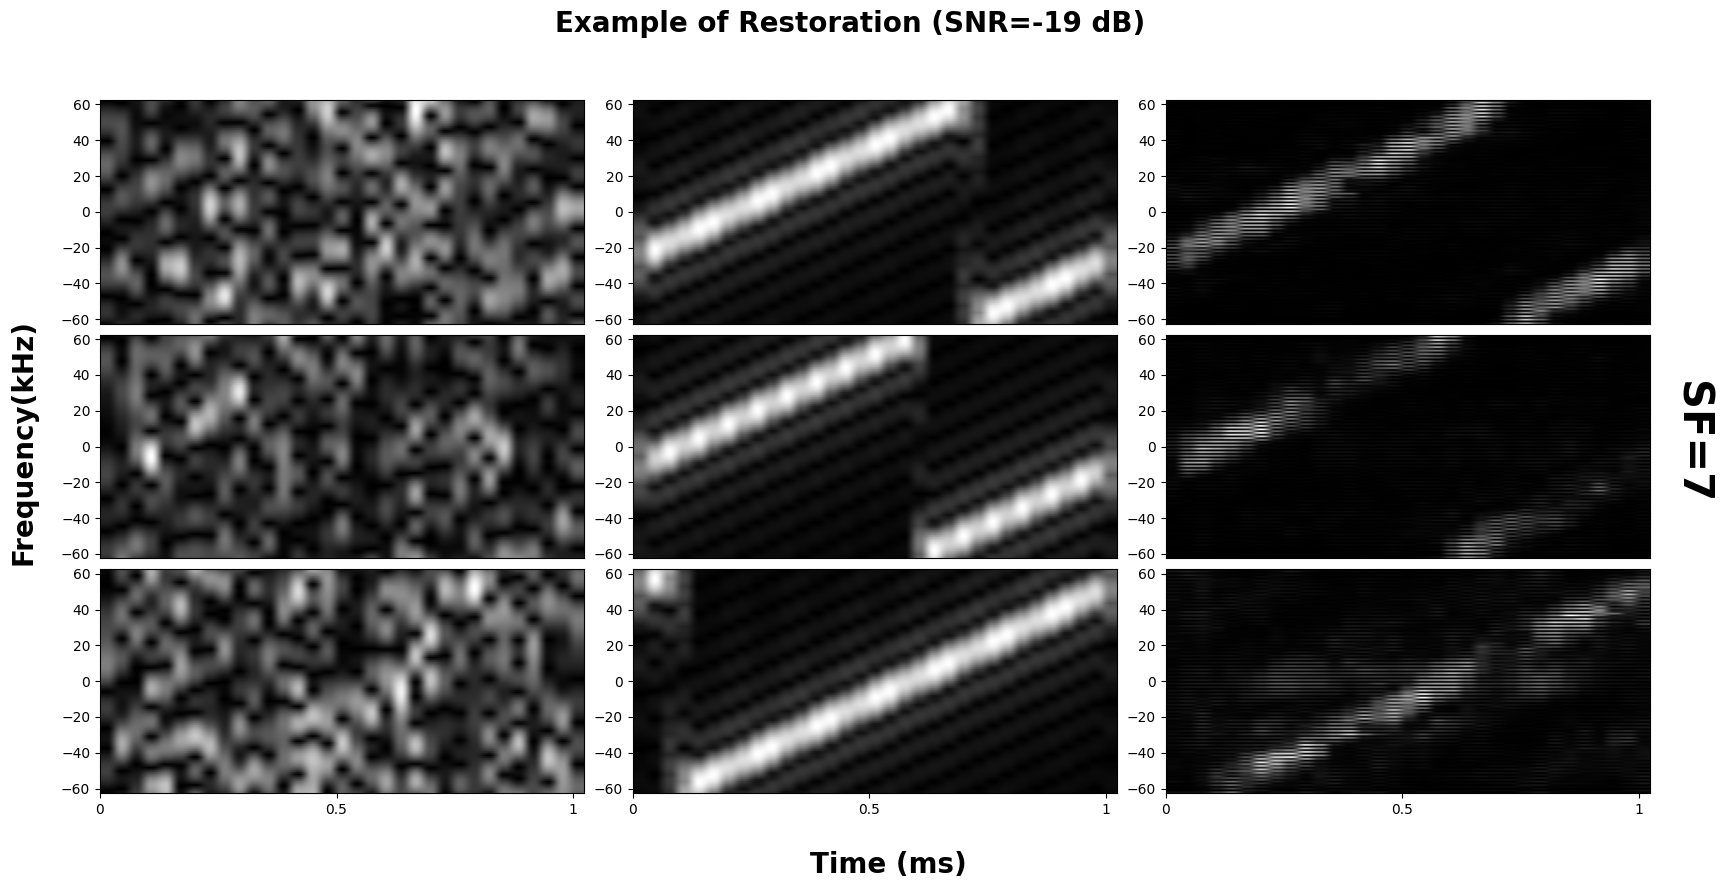

In [ ]:
split_per_snr_list = torch.stack(split_per_snr[an_idx])
split_per_gt_list = torch.stack(split_per_gt[an_idx])
images_X_test_spectrum_raw = torch.stft(input=split_per_snr_list, n_fft=opts.stft_nfft,
                                                    hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                    pad_mode='constant')

images_X_test_spectrum = spec_to_network_input(images_X_test_spectrum_raw, opts)

images_Y_test_spectrum_raw = torch.stft(input=split_per_gt_list, n_fft=opts.stft_nfft,
                                                    hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                    pad_mode='constant')

images_Y_test_spectrum = spec_to_network_input(images_Y_test_spectrum_raw, opts)

x_ticks = {7: [0,0.5,1], 8: [0,1,2], 9: [0,2,4]}
x_ticks_labels = {7: ["0", "0.5", "1"], 8: ["0", "1", "2"], 9: ["0", "2", "4"]}

# images_X_test_spectrum : [B, C, H, W]
size = 3
pred_mask = model_calora(images_X_test_spectrum)
print(f' shape : {(torch.abs(pred_mask[:,0,:,:]) + torch.abs(pred_mask[:,1,:,:])).shape}')
an_cmap = 'gray'

fig, axes = plt.subplots(size,3, figsize=(20,3.0*size), sharey=True)
plt.suptitle(f'Example of Restoration (SNR={an_idx} dB)', fontsize=20, fontweight='bold')
for i in range(size):
    an = images_X_test_spectrum[i][0].cpu()
    an_pred_mask = pred_mask[i][0].cpu()
    an_pred_mask_imag = pred_mask[i][1].cpu()
    an_gt = images_Y_test_spectrum[i][0].cpu()
    an_gt_imag = images_Y_test_spectrum[i][1].cpu()
    an_list = [an, an_pred_mask, an_pred_mask_imag, an_gt, an_gt_imag]
    # an_title = [f'SNR : {an_idx} Label : {split_per_labels[an_idx][i]}', 'Ours', 'GT']
    
    for j in range(3):
        ax = axes[i,j] if size > 1 else axes[j]
        if j==2:
            with torch.no_grad():
                img = (torch.abs(an_list[1]) + torch.abs(an_list[2])).numpy()
        elif j == 1:
            with torch.no_grad():
                img = (torch.abs(an_list[3]) + torch.abs(an_list[4])).numpy()
        else:
            img = torch.abs(an_list[j]).numpy()
        ax.imshow(img, aspect='auto', origin='lower', cmap=an_cmap, extent=[0,2**opts.sf/125,-62.5,62.5])
        ax.tick_params(axis='y', which='both', left=True, labelleft=True)
        if i == size-1:
            ax.set_xticks(x_ticks[opts.sf])
            ax.set_xticklabels(x_ticks_labels[opts.sf])
        else:
            ax.set_xticks([])
        ax.set_ylim(-62.5,62.5)


fig.text(0.08, 0.5, 'Frequency(kHz)', va='center', rotation=90, fontsize=20, fontweight='bold')
fig.text(0.91, 0.5, f'SF={opts.sf}', va='center', rotation=270, fontsize=30, fontweight='bold')
fig.text(0.48, 0.03, f'Time (ms)', va='center', rotation=0, fontsize=20, fontweight='bold')

plt.subplots_adjust(wspace=0.1, hspace=0.05)  
# plt.tight_layout()
plt.show()


- 배치 사이즈 크기만큼 예측한 결과값 출력 (Random)

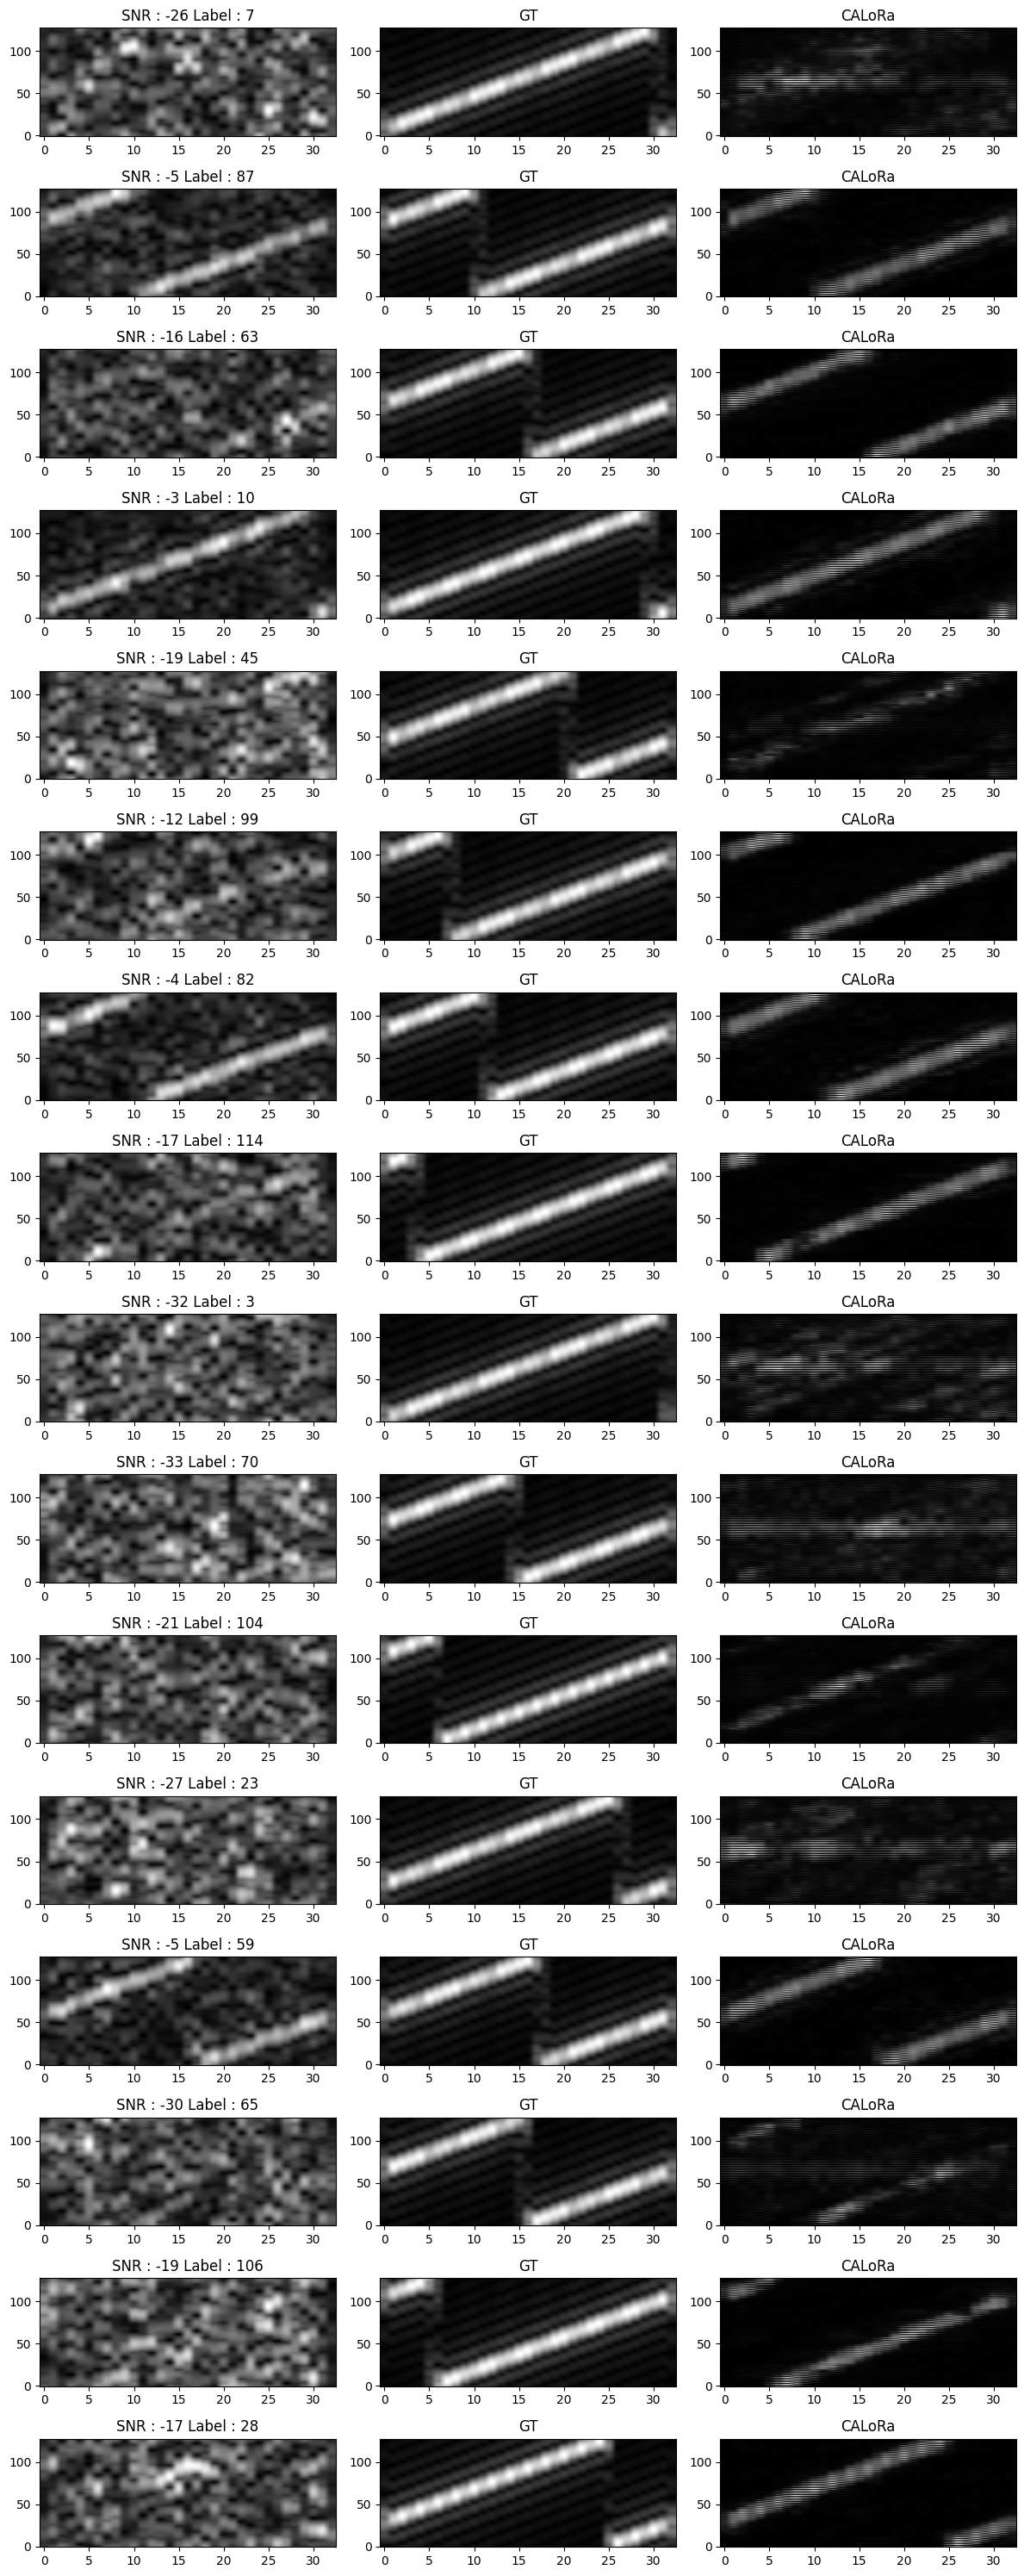

mean : 1.4730926523043308e-05


In [ ]:
images_X_test_spectrum_raw = torch.stft(input=images_X_test, n_fft=opts.stft_nfft,
                                                hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                pad_mode='constant')

images_X_test_spectrum = spec_to_network_input(images_X_test_spectrum_raw, opts)

images_Y_test_spectrum_raw = torch.stft(input=images_Y_test, n_fft=opts.stft_nfft,
                                        hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                        pad_mode='constant')

images_Y_test_spectrum = spec_to_network_input(images_Y_test_spectrum_raw, opts)

size = len(images_X_test_spectrum)
pred_mask = model_calora(images_X_test_spectrum)

an_cmap = 'gray'

plt.figure(figsize=(12,30))
for i in range(size):
    an = images_X_test_spectrum[i][0].cpu()
    an_imag = images_X_test_spectrum[i][1].cpu()

    an_pred_mask = pred_mask[i][0].cpu()
    an_pred_mask_imag = pred_mask[i][1].cpu()

    an_gt = images_Y_test_spectrum[i][0].cpu()
    an_gt_imag = images_Y_test_spectrum[i][1].cpu()

    an_list = [an, an_gt, an_pred_mask]
    an_list_imag = [an_imag, an_gt_imag, an_pred_mask_imag]
    an_title = [f'SNR : {snr_X_test_mapping[i]} Label : {labels_X_test_mapping[i]}', 'GT', 'CALoRa']
    
    for j in range(3):
        plt.subplot(size, 3, (3*i + (j+1)))
        plt.title(an_title[j])
        if j == 2:
            with torch.no_grad():
                plt.imshow(torch.abs(an_list[j]) + torch.abs(an_list_imag[j]), aspect='auto', origin='lower', cmap=an_cmap)
        else:
            plt.imshow(torch.abs(an_list[j]) + torch.abs(an_list_imag[j]), aspect='auto', origin='lower', cmap = an_cmap)
plt.tight_layout()
plt.show()

print(f'mean : {torch.mean(an_list[1])}')

## 모델 Loss 정리

이 노트북에서는 학습이 끝난 후, **iteration(또는 step) 단위로 기록된 손실값**들을 한눈에 보기 위해 표 형태로 정리한다.  
기록하는 Loss 항목은 다음과 같다.

- **MSE Loss**  
  - 스펙트로그램 이미지를 기반으로 계산하는 회귀 손실  
  - 입력 스펙트로그램과 복원된 스펙트로그램 사이의 **Mean Squared Error**  
  - 모델이 스펙트로그램을 얼마나 잘 복원하는지를 나타낸다.

- **BCE Loss (Classification Loss)**  
  - 심볼 값 또는 클래스에 대해 계산하는 **Binary Cross Entropy** 손실  
  - 모델이 각 심볼/클래스를 얼마나 정확하게 분류하는지를 나타낸다.

- **Validation Loss**  
  - 검증용 데이터셋에 대해 계산한 손실  
  - 학습 중 **과적합 여부**와 모델의 일반화 성능을 확인하는 지표로 사용한다.

학습 과정에서 매 iteration마다 위 세 가지 Loss 값을 기록해 두었다가,  
다음과 같은 형태의 표로 정리해 확인한다.

<!-- | Iteration | MSE Loss (Spectrogram) | BCE Loss (Classification) | Validation Loss |
|----------:|------------------------|---------------------------|-----------------|
| 1         | …                      | …                         | …               |
| 2         | …                      | …                         | …               |
| …         | …                      | …                         | …               | -->

이 표를 통해,
- MSE와 BCE가 학습이 진행되면서 안정적으로 감소하는지,
- Validation Loss가 특정 시점 이후로 다시 증가하는지(과적합 징후),
등을 직관적으로 파악할 수 있다.

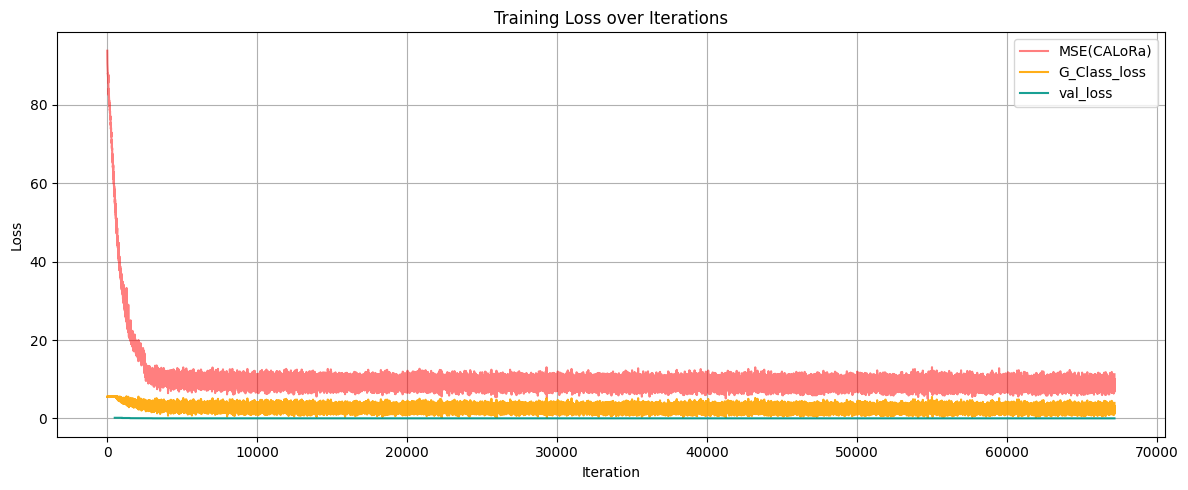

In [9]:
import pandas as pd

# 1. CSV 파일 읽기
log_df = pd.read_csv(f'../training_log_enhanced_sf{opts.sf}_ver5.csv')

# 2. Plot
plt.figure(figsize=(12, 5))
plt.plot(log_df['iteration'], log_df['G_Y_loss'], label='MSE(CALoRa)', color='red', alpha=0.5)
plt.plot(log_df['iteration'], log_df['G_Class_loss'], label='G_Class_loss', color='orange', alpha=0.9)
plt.plot(log_df['iteration'], log_df['Val_Loss'], label='val_loss', color='#009688', alpha=0.9)

# 3. 꾸미기
plt.title("Training Loss over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- 디코딩 성능 평가 (Vs. NELoRa)
    - Restoration Model : NELoRa 모델 불러오기
    - Classification Model : NELoRa, CALoRa의 Restoration Model을 기반으로 학습한 분류 모델 불러오기

In [115]:
model_nelora = maskCNNModel(opts).to(device)
model_nelora.load_state_dict(torch.load(f'../weights/best_model_CNNTrans_train_sf{opts.sf}_with_class_denoising_nelora.pth'))

C_XtoY_nelora = classificationHybridModel(conv_dim_in=opts.y_image_channel,
                                    conv_dim_out=opts.conv_dim_out_,
                                    conv_dim_lstm=opts.conv_dim_lstm_).to(device)

C_XtoY_nelora.load_state_dict(torch.load(f'../weights/best_model_CNNTrans_train_sf{opts.sf}_with_class_classification_nelora.pth'))

C_XtoY_calora = classificationHybridModel(conv_dim_in=opts.y_image_channel,
                                    conv_dim_out=opts.conv_dim_out_,
                                    conv_dim_lstm=opts.conv_dim_lstm_).to(device)

C_XtoY_calora.load_state_dict(torch.load(f'../training_log_enhanced_sf{opts.sf}_classification_ver5.pth'))

<All keys matched successfully>

In [116]:
test_iter_X = iter(testing_dataloader_X)        # Noisy Symbols for test
test_iter_Y = iter(testing_dataloader_Y)        # GT

images_X_test, name_X_test = next(test_iter_X)
images_Y_test, name_Y_test = next(test_iter_Y)

images_Y_test = to_var(images_Y_test)

print(f'Total testdata set : {len(testing_dataloader_X)}')
print(f'Test Shape : {images_X_test.shape}')

Total testdata set : 16794
Test Shape : torch.Size([16, 1024])


In [117]:
model_calora.eval()
model_nelora.eval()
C_XtoY_nelora.eval()
C_XtoY_calora.eval()

classificationHybridModel(
  (conv1): Conv2d(2, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dense): Linear(in_features=4096, out_features=512, bias=True)
  (fcn1): Linear(in_features=512, out_features=256, bias=True)
  (fcn2): Linear(in_features=256, out_features=128, bias=True)
  (softmax): Softmax(dim=1)
  (drop1): Dropout(p=0.2, inplace=False)
  (drop2): Dropout(p=0.5, inplace=False)
  (act): ReLU()
)

In [131]:
def adjacent_accuracy(pred_list, actual_list, value_range=512):
    """
    예측 리스트와 실제 리스트 간 인접 판정 후 정답률 계산
    조건: 동일값 또는 ±1 (원형 구조에서 0과 최대값도 인접)
    
    Parameters:
        pred_list (list[int]): 예측값 리스트 (예: 길이 16)
        actual_list (list[int]): 실제값 리스트 (예: 길이 16)
        value_range (int): 값의 전체 범위 (기본 256)
        
    Returns:
        tuple:
            matches (list[bool]): 각 위치별 인접 여부
            accuracy (float): 정답률 (0~1)
    """
    matches = []
    for pred, actual in zip(pred_list, actual_list):
        diff = abs(pred - actual)
        circular_diff = min(diff, value_range - diff)
        matches.append(circular_diff <= 1)
    
    accuracy = sum(matches) / len(matches) if matches else 0.0
    return matches, accuracy

In [ ]:
test_snrs = []
test_labels = []

calora_labels = []
nelora_labels = []

count = 0
test_iter_X = iter(testing_dataloader_X)        # Noisy Symbols for test
test_iter_Y = iter(testing_dataloader_Y)        # GT
with torch.no_grad():
    for i, batch in enumerate(testing_dataloader_X):
        print(f'COUNT : {count} / {len(testing_dataloader_X)-1}')
        images_X_test, name_X_test = next(test_iter_X)
        images_Y_test, name_Y_test = next(test_iter_Y)
        images_Y_test = to_var(images_Y_test)

        snr_X_test_mapping = list(
            map(lambda x: int(x.split('_')[1]), name_X_test))

        labels_X_test_mapping = list(
            map(lambda x: int(x.split('_')[5]), name_X_test))

        images_X_test, labels_X_test = to_var(images_X_test), to_var(
            torch.tensor(labels_X_test_mapping))
        
        images_X_test_spectrum_raw = torch.stft(input=images_X_test, n_fft=opts.stft_nfft,
                                                    hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                    pad_mode='constant')

        images_X_test_spectrum = spec_to_network_input(images_X_test_spectrum_raw, opts)

        images_Y_test_spectrum_raw = torch.stft(input=images_Y_test, n_fft=opts.stft_nfft,
                                                hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                pad_mode='constant')
        
        images_Y_test_spectrum = spec_to_network_input(images_Y_test_spectrum_raw, opts)

        output_nelora = model_nelora(images_X_test_spectrum)
        output_calora = model_calora(images_X_test_spectrum)

        test_labels.append(labels_X_test_mapping)
        test_snrs.append(snr_X_test_mapping)

        # Predict : maskCNN + class1
        pred_result_nelora = output_nelora
        labels_X_estimated = C_XtoY_nelora(pred_result_nelora)
        _, labels_X_estimated = torch.max(labels_X_estimated, 1)
        nelora_labels.append(labels_X_estimated)

        # Predict : transCNN + class2
        pred_result_calora = output_calora
        labels_X_estimated2 = C_XtoY_calora(pred_result_calora)
        _, labels_X_estimated2 = torch.max(labels_X_estimated2, 1)
        calora_labels.append(labels_X_estimated2)


        count += 1

COUNT : 0
COUNT : 1
COUNT : 2
COUNT : 3
COUNT : 4
COUNT : 5
COUNT : 6
COUNT : 7
COUNT : 8
COUNT : 9
COUNT : 10
COUNT : 11
COUNT : 12
COUNT : 13
COUNT : 14
COUNT : 15
COUNT : 16
COUNT : 17
COUNT : 18
COUNT : 19
COUNT : 20
COUNT : 21
COUNT : 22
COUNT : 23
COUNT : 24
COUNT : 25
COUNT : 26
COUNT : 27
COUNT : 28
COUNT : 29
COUNT : 30
COUNT : 31
COUNT : 32
COUNT : 33
COUNT : 34
COUNT : 35
COUNT : 36
COUNT : 37
COUNT : 38
COUNT : 39
COUNT : 40
COUNT : 41
COUNT : 42
COUNT : 43
COUNT : 44
COUNT : 45
COUNT : 46
COUNT : 47
COUNT : 48
COUNT : 49
COUNT : 50
COUNT : 51
COUNT : 52
COUNT : 53
COUNT : 54
COUNT : 55
COUNT : 56
COUNT : 57
COUNT : 58
COUNT : 59
COUNT : 60
COUNT : 61
COUNT : 62
COUNT : 63
COUNT : 64
COUNT : 65
COUNT : 66
COUNT : 67
COUNT : 68
COUNT : 69
COUNT : 70
COUNT : 71
COUNT : 72
COUNT : 73
COUNT : 74
COUNT : 75
COUNT : 76
COUNT : 77
COUNT : 78
COUNT : 79
COUNT : 80
COUNT : 81
COUNT : 82
COUNT : 83
COUNT : 84
COUNT : 85
COUNT : 86
COUNT : 87
COUNT : 88
COUNT : 89
COUNT : 90
COUNT : 9

- test_labels : 실제 심볼 값
- calora_labels : CALoRa가 예측한 심볼 값
- nelora_labels : NELoRa가 예측한 실볼 값

In [180]:
list_size = len(testing_dataloader_X)-1

calora_labels_numpy = np.array([t.cpu().numpy() for t in calora_labels[:list_size]])
nelora_labels_numpy = np.array([t.cpu().numpy() for t in nelora_labels[:list_size]])

print(f'test_snrs shape : {np.shape(test_snrs[:list_size])}')
print('='*95)
comparison_df = pd.DataFrame({
    'SNR': test_snrs[0],
    'GT Label': test_labels[0],
    'CaLoRa Pred': calora_labels[0].cpu(),
    'NeLoRa Pred': nelora_labels[0].cpu()
})

# 1. 세로로 길게 보기 (추천: 값 비교가 가장 쉬움)
display(comparison_df)

test_snrs shape : (16793, 16)


,SNR,GT Label,CaLoRa Pred,NeLoRa Pred
0,-29,19,114,107
1,-14,19,19,19
2,-22,54,41,43
3,-35,46,70,73
4,-23,3,106,47
5,-9,107,107,107
6,-40,110,21,116
7,-6,85,85,85
8,-20,26,26,61
9,-27,68,15,57


- nelora

In [133]:
calora_count = 0
nelora_count = 0

calora_adjacent_count = 0
nelora_adjacent_count = 0


for i in range(list_size):
    correct_nelora = (nelora_labels_numpy[i] == test_labels[i])
    correct_nelora_sum = np.sum(correct_nelora)

    correct_calora = (calora_labels_numpy[i] == test_labels[i])
    correct_calora_sum = np.sum(correct_calora)

    nelora_count += correct_nelora_sum
    calora_count += correct_calora_sum

    matches, acc = adjacent_accuracy(calora_labels_numpy[i], test_labels[i])
    correct_calora_adjacent_sum = np.sum(matches)
    calora_adjacent_count += correct_calora_adjacent_sum

    matches_, acc_ = adjacent_accuracy(nelora_labels_numpy[i], test_labels[i])
    correct_nelora_adjacent_sum = np.sum(matches_)
    nelora_adjacent_count += correct_nelora_adjacent_sum

    
total_count = int(list_size*16)
print(f'nelora_count : {nelora_count}({(nelora_count/total_count):.2f}%)')
print(f'calora_count : {calora_count}({(calora_count/total_count):.2f}%)')
print(f'nelora_adjacent_count : {nelora_adjacent_count}({(nelora_adjacent_count/total_count):.2f}%)')
print(f'calora_adjacent_count : {calora_adjacent_count}({(calora_adjacent_count/total_count):.2f}%)')


nelora_count : 134083(0.50%)
calora_count : 156715(0.58%)
nelora_adjacent_count : 137131(0.51%)
calora_adjacent_count : 159424(0.59%)


In [ ]:
low_snrs_calora = np.zeros(len(np.unique(test_snrs[:list_size])), dtype=np.int32)
low_snrs_nelora = np.zeros(len(np.unique(test_snrs[:list_size])), dtype=np.int32)

low_snrs_calora_adjacent = np.zeros(len(np.unique(test_snrs[:list_size])), dtype=np.int32)
low_snrs_nelora_adjacent = np.zeros(len(np.unique(test_snrs[:list_size])), dtype=np.int32)


for i in range(list_size):
    # for snr in test_snrs[i]:
    correct_nelora = (nelora_labels_numpy[i] == test_labels[i])
    # print(correct_nelora)
    correct_transCNN = (calora_labels_numpy[i] == test_labels[i])

    matches, acc = adjacent_accuracy(calora_labels_numpy[i], test_labels[i])
    correct_transCNN_adjacent = (matches)

    matches_, acc_ = adjacent_accuracy(nelora_labels_numpy[i], test_labels[i])
    correct_nelora_adjacent = (matches_)

    for j, snr in enumerate(test_snrs[i]):
        if correct_nelora[j] == True:
            low_snrs_nelora[np.abs(snr)] += 1
        if correct_transCNN[j] == True:
            low_snrs_calora[np.abs(snr)] += 1
        if correct_transCNN_adjacent[j] == True:
            low_snrs_calora_adjacent[np.abs(snr)] += 1
        if correct_nelora_adjacent[j] == True:
            low_snrs_nelora_adjacent[np.abs(snr)] += 1
        
flattened = [item for sublist in test_snrs for item in sublist]
# 고윳값 개수 세기
value_counts = Counter(flattened)

# 출력
dict_nelora = {}
dict_calora = {}
dict_calora_adjacent = {}
dict_nelora_adjacent = {}
c_ = 0
for value, count in sorted(value_counts.items()):
    # print(f"SNR {value}: {count}개")
    dict_nelora[value] = low_snrs_nelora[::-1][c_]/count
    dict_calora[value] = low_snrs_calora[::-1][c_]/count
    dict_calora_adjacent[value] = low_snrs_calora_adjacent[::-1][c_]/count
    dict_nelora_adjacent[value] = low_snrs_nelora_adjacent[::-1][c_]/count
    c_ += 1

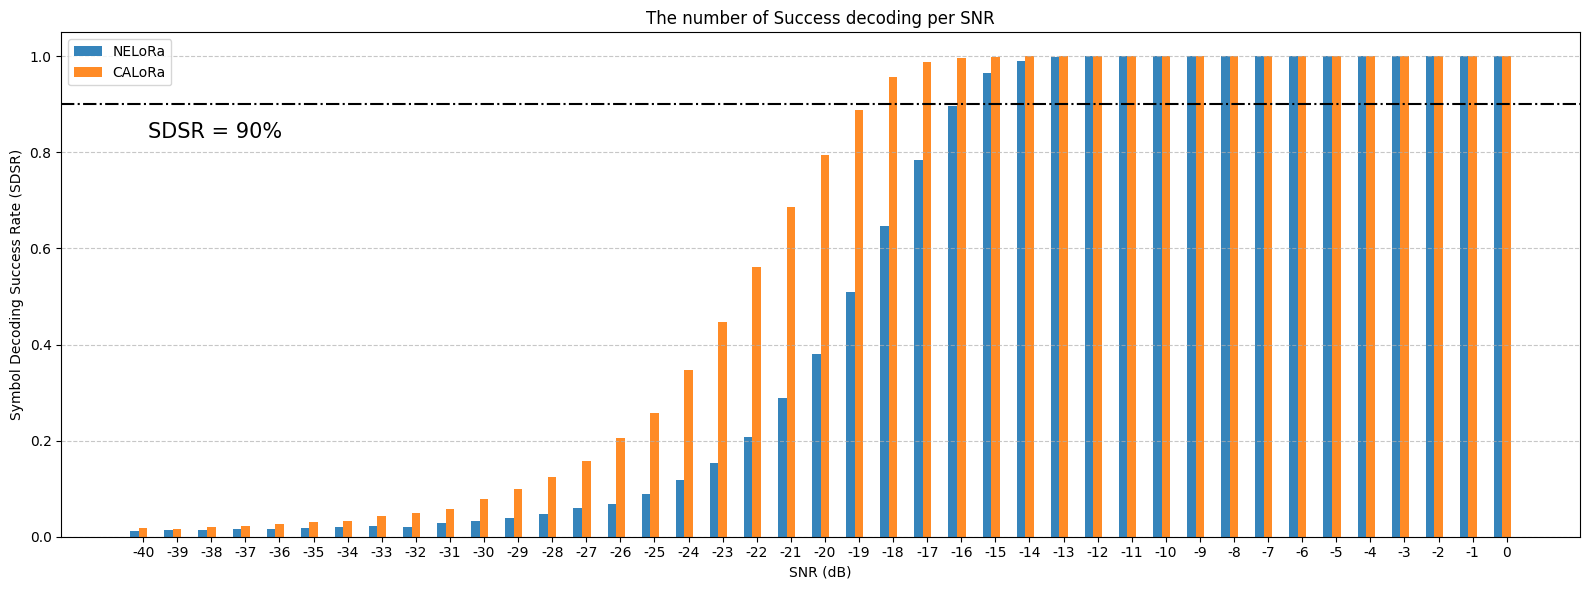

In [151]:
# 예시 x값
x = np.arange(-40, 1)  # [-25, -24, ..., 0]

nelora_list = list(dict_nelora.values())
calora_list = list(dict_calora.values())
calora_adjacent_list = list(dict_calora_adjacent.values())
nelora_adjacent_list = list(dict_nelora_adjacent.values())

# bar 너비 설정
indices = np.arange(len(x))  # 막대 위치용 인덱스
width = 0.25

plt.figure(figsize=(16,6))
plt.title('The number of Success decoding per SNR')

# 각 막대 그리기 (x 위치를 살짝 옆으로 옮겨줌)
plt.bar(indices - width, nelora_list, width=width, label='NELoRa', alpha=0.9)
plt.bar(indices, calora_list, width=width, label='CALoRa', alpha=0.9)
# plt.bar(indices+width, calora_adjacent_list, width=width, label='CALoRa_adjacent', alpha=0.9)
plt.axhline(0.9, linestyle='-.', color='black')

# x축 눈금과 라벨 설정
plt.xticks(indices, x)  # x축에 실제 SNR 값 표시
plt.xlabel('SNR (dB)')
plt.ylabel('Symbol Decoding Success Rate (SDSR)')
plt.legend()
plt.text(0.13,0.83,'SDSR = 90%', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()